<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/root_mean_square_error.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [4]:
!fusermount -u /content/drive

fusermount: failed to unmount /content/drive: No such file or directory


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH,header=None)
test  = pd.read_csv(TEST_PATH,header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


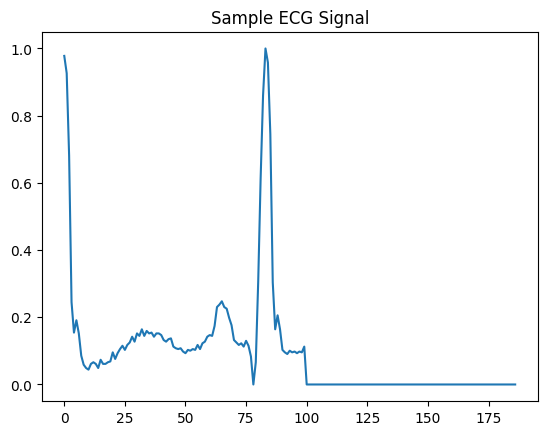

In [7]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

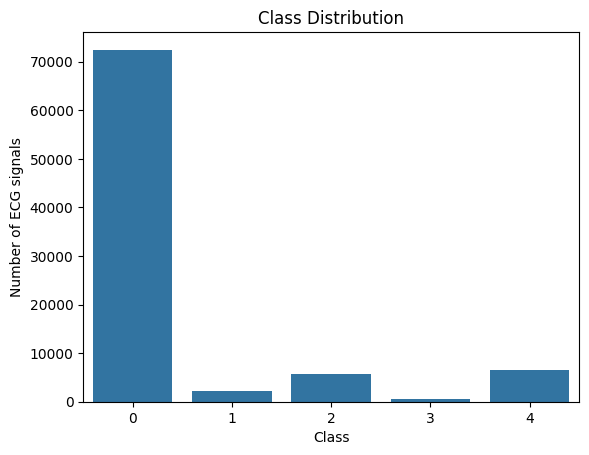

In [8]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [9]:
print("Missing values train:",train.isna().sum().sum())
print("Missing values test:",test.isna().sum().sum())

Missing values train: 0
Missing values test: 0


In [10]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [11]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [12]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [13]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [14]:
def rmse_loss(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))


def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=rmse_loss,
        metrics=['accuracy']
    )

    return model

In [16]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 198s 50ms/step - accuracy: 0.9386 - loss: 0.1282
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 183s 48ms/step - accuracy: 0.9714 - loss: 0.0877
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 206s 49ms/step - accuracy: 0.9786 - loss: 0.0741
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 196s 48ms/step - accuracy: 0.9822 - loss: 0.0658
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 202s 48ms/step - accuracy: 0.9842 - loss: 0.0608

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 204s 53ms/step - accuracy: 0.9368 - loss: 0.1308
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 199s 53ms/step - accuracy: 0.9712 - loss: 0.0885
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 194s 51ms/step - accuracy: 0.9788 - loss: 0.0739
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 203s 52ms/step - accuracy: 0.9820 - loss: 0.0659
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 196s 52ms/step - accuracy: 0.9847 - loss: 0.0593

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 216s 56ms/step - accuracy: 0.9376 -

In [17]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [18]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 295s 64ms/step - accuracy: 0.9419 - loss: 0.1250 - val_accuracy: 0.9301 - val_loss: 0.1420
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 269s 59ms/step - accuracy: 0.9742 - loss: 0.0834 - val_accuracy: 0.9537 - val_loss: 0.1135
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 261s 58ms/step - accuracy: 0.9806 - loss: 0.0699 - val_accuracy: 0.9712 - val_loss: 0.0883
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 251s 55ms/step - accuracy: 0.9833 - loss: 0.0630 - val_accuracy: 0.9737 - val_loss: 0.0846
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 251s 53ms/step - accuracy: 0.9858 - loss: 0.0566 - val_accuracy: 0.8402 - val_loss: 0.2283
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 244s 54ms/step - accuracy: 0.9868 - loss: 0.0537 - val_accuracy: 0.9751 - val_loss: 0.0815
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 246s 54ms/step - accuracy: 0.9850 - loss: 0.0583 - val_accuracy: 0.7779 - val_loss: 0.2717
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 277s 58ms/step - accuracy: 

In [19]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)

val_mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", val_mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step
Validation MCC: 0.9696462797153722


Final Training Accuracy: 0.988295316696167
Final Validation Accuracy: 0.9755626320838928


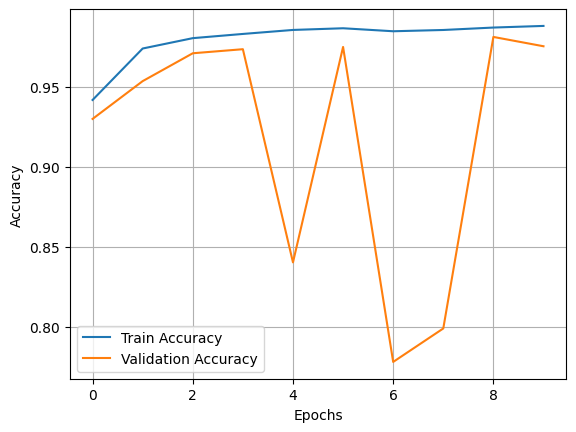

In [21]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Final Training Loss: 0.04895535856485367
Final Validation Loss: 0.08077022433280945


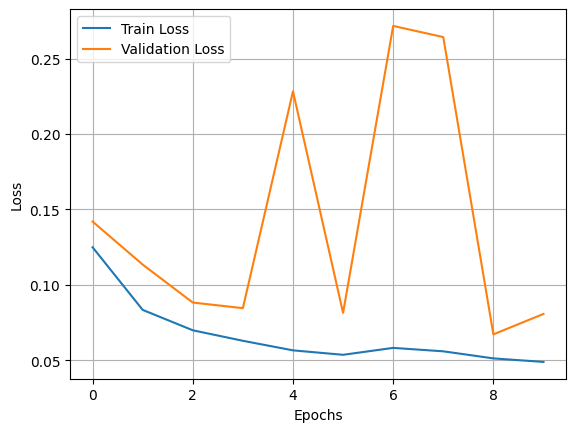

In [22]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

# ===============================
# Classification Report + Specificity
# ===============================

report = classification_report(y_test, y_test_pred, output_dict=True)
cm = confusion_matrix(y_test, y_test_pred)

print("\n{:<10} {:<10} {:<10} {:<10} {:<10} {:<10}".format(
    "Class", "Precision", "Recall", "F1-score", "Specificity", "Support"
))

specificities = []

for i, label in enumerate(report.keys()):
    if label not in ['accuracy', 'macro avg', 'weighted avg']:

        precision = report[label]['precision']
        recall = report[label]['recall']
        f1 = report[label]['f1-score']
        support = int(report[label]['support'])

        # Specificity calculation
        TN = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        FP = np.sum(cm[:, i]) - cm[i, i]
        specificity = TN / (TN + FP + 1e-7)

        specificities.append(specificity)

        print("{:<10} {:<10.2f} {:<10.2f} {:<10.2f} {:<10.2f} {:<10}".format(
            label, precision, recall, f1, specificity, support
        ))

# Accuracy
print("\nAccuracy:", report['accuracy'])

# Macro Avg
macro_spec = np.mean(specificities)
print("\nMacro Avg Specificity:", macro_spec)

Test Loss: 0.13680028915405273
Test Accuracy: 0.9339484572410583
685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step

Class      Precision  Recall     F1-score   Specificity Support   
0.0        0.99       0.93       0.96       0.97       18118     
1.0        0.31       0.87       0.46       0.95       556       
2.0        0.90       0.96       0.93       0.99       1448      
3.0        0.69       0.80       0.74       1.00       162       
4.0        0.98       0.97       0.98       1.00       1608      

Accuracy: 0.9339484743285218

Macro Avg Specificity: 0.9814880098007676


In [24]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

# ===============================
# Specificity Calculation
# ===============================

cm = confusion_matrix(y_test, y_test_pred)

specificity_list = []

for i in range(len(cm)):
    TN = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
    FP = np.sum(cm[:, i]) - cm[i, i]

    specificity = TN / (TN + FP + 1e-7)
    specificity_list.append(specificity)

print("Class-wise Specificity:", specificity_list)
print("Mean Specificity:", np.mean(specificity_list))

Test Loss: 0.13680028915405273
Test Accuracy: 0.9339484572410583
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96     18118
         1.0       0.31      0.87      0.46       556
         2.0       0.90      0.96      0.93      1448
         3.0       0.69      0.80      0.74       162
         4.0       0.98      0.97      0.98      1608

    accuracy                           0.93     21892
   macro avg       0.77      0.91      0.81     21892
weighted avg       0.97      0.93      0.95     21892

Class-wise Specificity: [np.float64(0.9703232644152008), np.float64(0.9492875890469193), np.float64(0.992075914688945), np.float64(0.9973308789645774), np.float64(0.9984224018881954)]
Mean Specificity: 0.9814880098007676


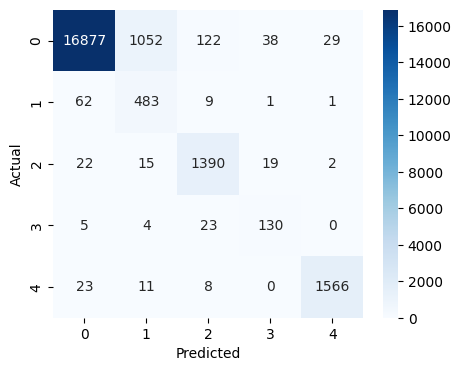

In [25]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()